# 16. PoC 한계 분석 · 모델 배포 최적화 실습

## 학습 목표
1. 현재 PoC 시스템의 **기술·데이터·운영 한계**를 구조적으로 분석한다.
2. PoC → Production **갭(Gap)** 을 정량화한다.
3. **배포 최적화**(경량화·배치·캐시·엣지)를 실습하고 개선 효과를 측정한다.

---

## PoC vs Production 관점

| 구분 | PoC (현재) | Production (목표) |
|------|------------|-------------------|
| 데이터 | 정적 데이터셋, 시뮬 센서 | 실시간 MES/센서 스트림 |
| 모델 | Rule/Mock LLM, 경량 feature | 학습된 검출 모델 + 검증된 LLM |
| 지연 | 노트북 인프로세스 | p95 < 100ms @ Edge |
| 신뢰성 | 수동 테스트 | SLA 99.5%, 자동 알람 |
| 확장 | 단일 라인 | 다라인·다제품 |

In [1]:
from pathlib import Path
from datetime import datetime
import json
import time
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT / "data" / "pcb-defect-dataset" / "pcb-defect-dataset"
OUT_DIR = PROJECT_ROOT / "outputs" / "poc_limits_deployment"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT exists:", DATA_ROOT.exists())
print("OUT_DIR:", OUT_DIR)

DATA_ROOT exists: True
OUT_DIR: C:\MyCursorLab\10_프로젝트\outputs\poc_limits_deployment


## 1) PoC 시스템 한계 분석 프레임워크

5개 축으로 한계를 분류합니다.

1. **데이터** — 커버리지, 라벨 품질, 실시간성
2. **모델** — 성능 상한, 일반화, 설명 가능성
3. **시스템** — 지연, 처리량, 장애 복구
4. **운영** — 모니터링, 피드백 루프, 버전 관리
5. **비즈니스** — ROI 검증, 현장 수용성, 규제

In [2]:
POC_LIMITS = [
    {"axis": "데이터", "id": "D1", "limit": "이미지-라벨 불일치 stem 존재", "severity": "high", "evidence": "02/06 노트북 스킵 로직", "mitigation": "정제 파이프라인 + 품질 게이트"},
    {"axis": "데이터", "id": "D2", "limit": "센서 데이터 시뮬레이션 의존", "severity": "high", "evidence": "03/11 노트북", "mitigation": "실측 센서 API 연동"},
    {"axis": "데이터", "id": "D3", "limit": "단일 제품/조명 조건 편향", "severity": "medium", "evidence": "light_XX 분포", "mitigation": "현장 도메인 적응 데이터 수집"},
    {"axis": "모델", "id": "M1", "limit": "Rule-based risk score (학습 모델 미배포)", "severity": "high", "evidence": "11번 VisionModule", "mitigation": "YOLO/CNN 학습 모델 배포"},
    {"axis": "모델", "id": "M2", "limit": "Mock LLM (실 API 미연동)", "severity": "medium", "evidence": "12번 MockLLM", "mitigation": "검증된 LLM + 가드레일"},
    {"axis": "모델", "id": "M3", "limit": "mAP 평가가 시뮬 예측 기반 구간 존재", "severity": "medium", "evidence": "08-10 노트북", "mitigation": "실추론 결과 자동 평가"},
    {"axis": "시스템", "id": "S1", "limit": "인프로세스 웹서비스 (분산/오토스케일 없음)", "severity": "high", "evidence": "13번", "mitigation": "컨테이너 + K8s/Edge 배포"},
    {"axis": "시스템", "id": "S2", "limit": "단건 추론 중심", "severity": "medium", "evidence": "14번 벤치", "mitigation": "배치/파이프라인 최적화"},
    {"axis": "운영", "id": "O1", "limit": "모니터링 시뮬레이션 단계", "severity": "medium", "evidence": "15번", "mitigation": "Prometheus/Grafana 실연동"},
    {"axis": "운영", "id": "O2", "limit": "피드백 기반 설정 자동화 초기 수준", "severity": "low", "evidence": "13 FeedbackReflector", "mitigation": "A/B + 승인 워크플로"},
    {"axis": "비즈니스", "id": "B1", "limit": "ROI 가정치 기반 (실측 미검증)", "severity": "medium", "evidence": "01번 ROI 실습", "mitigation": "3개월 파일럿 KPI 측정"},
]

limits_df = pd.DataFrame(POC_LIMITS)
limits_df["severity_score"] = limits_df["severity"].map({"low": 1, "medium": 2, "high": 3})

display(limits_df)
print("\n축별 한계 건수:")
display(limits_df.groupby("axis").size().rename("count"))
print("\n심각도 분포:")
display(limits_df["severity"].value_counts())

,axis,id,limit,severity,evidence,mitigation,severity_score
0,데이터,D1,이미지-라벨 불일치 stem 존재,high,02/06 노트북 스킵 로직,정제 파이프라인 + 품질 게이트,3
1,데이터,D2,센서 데이터 시뮬레이션 의존,high,03/11 노트북,실측 센서 API 연동,3
2,데이터,D3,단일 제품/조명 조건 편향,medium,light_XX 분포,현장 도메인 적응 데이터 수집,2
3,모델,M1,Rule-based risk score (학습 모델 미배포),high,11번 VisionModule,YOLO/CNN 학습 모델 배포,3
4,모델,M2,Mock LLM (실 API 미연동),medium,12번 MockLLM,검증된 LLM + 가드레일,2
5,모델,M3,mAP 평가가 시뮬 예측 기반 구간 존재,medium,08-10 노트북,실추론 결과 자동 평가,2
6,시스템,S1,인프로세스 웹서비스 (분산/오토스케일 없음),high,13번,컨테이너 + K8s/Edge 배포,3
7,시스템,S2,단건 추론 중심,medium,14번 벤치,배치/파이프라인 최적화,2
8,운영,O1,모니터링 시뮬레이션 단계,medium,15번,Prometheus/Grafana 실연동,2
9,운영,O2,피드백 기반 설정 자동화 초기 수준,low,13 FeedbackReflector,A/B + 승인 워크플로,1



축별 한계 건수:


axis
데이터     3
모델      3
비즈니스    1
시스템     2
운영      2
Name: count, dtype: int64


심각도 분포:


severity
medium    6
high      4
low       1
Name: count, dtype: int64

## 2) PoC → Production 갭 분석 (성숙도 점수)

각 축을 1~5점으로 평가하고 목표와의 갭을 계산합니다.

,axis,poc_score,target_score,weight,gap,weighted_gap
0,데이터,2.5,4.5,0.25,2.0,0.50
1,모델,2.0,4.5,0.30,2.5,0.75
2,시스템,2.5,4.0,0.20,1.5,0.30
3,운영,2.0,4.0,0.15,2.0,0.30
4,비즈니스,3.0,4.0,0.10,1.0,0.10


종합 PoC 성숙도: 2.33 / 5.0
목표 성숙도    : 4.27 / 5.0
종합 갭        : 1.95


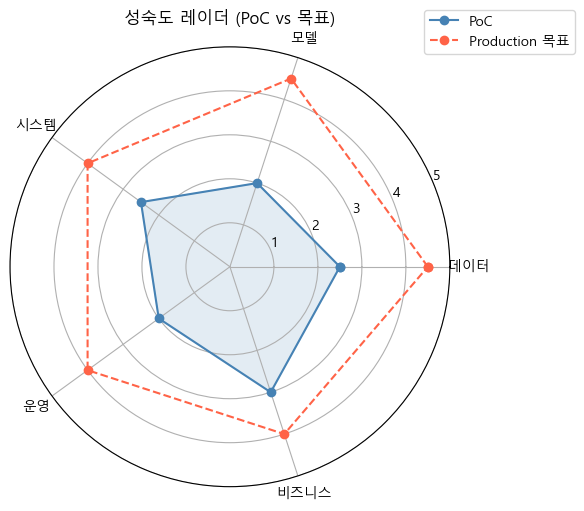

In [3]:
MATURITY = pd.DataFrame([
    {"axis": "데이터", "poc_score": 2.5, "target_score": 4.5, "weight": 0.25},
    {"axis": "모델", "poc_score": 2.0, "target_score": 4.5, "weight": 0.30},
    {"axis": "시스템", "poc_score": 2.5, "target_score": 4.0, "weight": 0.20},
    {"axis": "운영", "poc_score": 2.0, "target_score": 4.0, "weight": 0.15},
    {"axis": "비즈니스", "poc_score": 3.0, "target_score": 4.0, "weight": 0.10},
])

MATURITY["gap"] = MATURITY["target_score"] - MATURITY["poc_score"]
MATURITY["weighted_gap"] = MATURITY["gap"] * MATURITY["weight"]

overall_poc = (MATURITY["poc_score"] * MATURITY["weight"]).sum()
overall_target = (MATURITY["target_score"] * MATURITY["weight"]).sum()
overall_gap = overall_target - overall_poc

display(MATURITY)
print(f"종합 PoC 성숙도: {overall_poc:.2f} / 5.0")
print(f"목표 성숙도    : {overall_target:.2f} / 5.0")
print(f"종합 갭        : {overall_gap:.2f}")

# 레이더 차트 (간이)
angles = np.linspace(0, 2 * np.pi, len(MATURITY), endpoint=False).tolist()
angles += angles[:1]
poc_vals = MATURITY["poc_score"].tolist() + [MATURITY["poc_score"].iloc[0]]
tgt_vals = MATURITY["target_score"].tolist() + [MATURITY["target_score"].iloc[0]]
labels = MATURITY["axis"].tolist()

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, poc_vals, "o-", label="PoC", color="steelblue")
ax.fill(angles, poc_vals, alpha=0.15, color="steelblue")
ax.plot(angles, tgt_vals, "o--", label="Production 목표", color="tomato")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 5)
ax.set_title("성숙도 레이더 (PoC vs 목표)")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## 3) 모델 배포 최적화 실습

PoC의 **경량 feature 추론**을 배포 관점에서 최적화합니다.

| 전략 | 설명 |
|------|------|
| **Precision** | fp32 → fp16 메모리·대역폭 절감 |
| **Batch** | 배치 추론으로 GPU/CPU 활용률 향상 |
| **Cache** | 동일 이미지 재검사 시 스킵 |
| **Resize** | 입력 해상도 축소 (품질 trade-off) |
| **Warmup** | 첫 요청 지연 제거 |

In [4]:
img_paths = sorted((DATA_ROOT / "test" / "images").glob("*.jpg"))[:50]
images_fp32 = [np.array(Image.open(p).convert("L"), dtype=np.float32) / 255.0 for p in img_paths]


def infer_features_fp32(gray: np.ndarray) -> np.ndarray:
    """PoC baseline: 통계 + gradient feature (7D)."""
    mean, std = gray.mean(), gray.std()
    gx, gy = np.diff(gray, axis=1), np.diff(gray, axis=0)
    grad = (gx**2).mean() + (gy**2).mean()
    edge = (np.abs(gx) > 0.08).mean()
    p10, p50, p90 = np.percentile(gray, [10, 50, 90])
    return np.array([mean, std, p10, p50, p90, grad, edge], dtype=np.float32)


def infer_features_fp16(gray: np.ndarray) -> np.ndarray:
    g = gray.astype(np.float16).astype(np.float32)
    return infer_features_fp32(g)


def infer_features_resized(gray: np.ndarray, size=128) -> np.ndarray:
    im = Image.fromarray((gray * 255).astype(np.uint8)).resize((size, size), Image.BILINEAR)
    small = np.array(im, dtype=np.float32) / 255.0
    return infer_features_fp32(small)


class DeployCache:
    def __init__(self):
        self.store = {}
        self.hits = self.misses = 0

    def key(self, arr: np.ndarray) -> str:
        return hashlib.md5(arr.tobytes()).hexdigest()

    def get_or_compute(self, arr: np.ndarray, fn) -> np.ndarray:
        k = self.key(arr)
        if k in self.store:
            self.hits += 1
            return self.store[k]
        self.misses += 1
        out = fn(arr)
        self.store[k] = out
        return out


def bench_mode(images, fn, repeats=1, use_cache=False, cache=None):
    lat = []
    for _ in range(repeats):
        for im in images:
            t0 = time.perf_counter()
            if use_cache and cache:
                cache.get_or_compute(im, fn)
            else:
                fn(im)
            lat.append((time.perf_counter() - t0) * 1000)
    arr = np.array(lat)
    return {
        "mean_ms": float(arr.mean()),
        "p50_ms": float(np.percentile(arr, 50)),
        "p95_ms": float(np.percentile(arr, 95)),
        "throughput": float(1000.0 / (arr.mean() + 1e-9)),
    }

# Warmup
_ = [infer_features_fp32(im) for im in images_fp32[:3]]

cache = DeployCache()
dup_images = images_fp32 + images_fp32  # 캐시 hit 유도

results = [
    {"mode": "baseline_fp32", **bench_mode(images_fp32, infer_features_fp32)},
    {"mode": "optimized_fp16", **bench_mode(images_fp32, infer_features_fp16)},
    {"mode": "optimized_resize128", **bench_mode(images_fp32, lambda g: infer_features_resized(g, 128))},
    {"mode": "optimized_cache", **bench_mode(dup_images, infer_features_fp32, use_cache=True, cache=cache)},
]

# 배치 시뮬레이션
def batch_infer(images, batch_size=8):
    lat = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]
        t0 = time.perf_counter()
        stack = np.stack(batch)
        _ = stack.mean(axis=(1, 2))
        _ = stack.std(axis=(1, 2))
        for g in batch:
            _ = infer_features_fp32(g)
        lat.append((time.perf_counter() - t0) * 1000)
    per_img = np.array(lat) / batch_size
    return {"mean_ms": float(per_img.mean()), "p50_ms": float(np.percentile(per_img, 50)), "p95_ms": float(np.percentile(per_img, 95)), "throughput": float(1000.0 / (per_img.mean() + 1e-9))}

results.append({"mode": "batch8_pipeline", **batch_infer(images_fp32, 8)})

bench_df = pd.DataFrame(results)
baseline_tp = bench_df.loc[bench_df["mode"] == "baseline_fp32", "throughput"].iloc[0]
bench_df["speedup_vs_baseline"] = bench_df["throughput"] / baseline_tp

display(bench_df.round(3))
print(f"cache hit rate: {cache.hits/(cache.hits+cache.misses):.1%}")

,mode,mean_ms,p50_ms,p95_ms,throughput,speedup_vs_baseline
0,baseline_fp32,6.721,6.662,7.622,148.790,1.000
1,optimized_fp16,7.782,7.734,8.560,128.500,0.864
2,optimized_resize128,1.504,1.372,2.135,664.918,4.469
3,optimized_cache,6.721,3.968,11.898,148.792,1.000
4,batch8_pipeline,14.335,14.980,19.329,69.758,0.469


cache hit rate: 51.0%


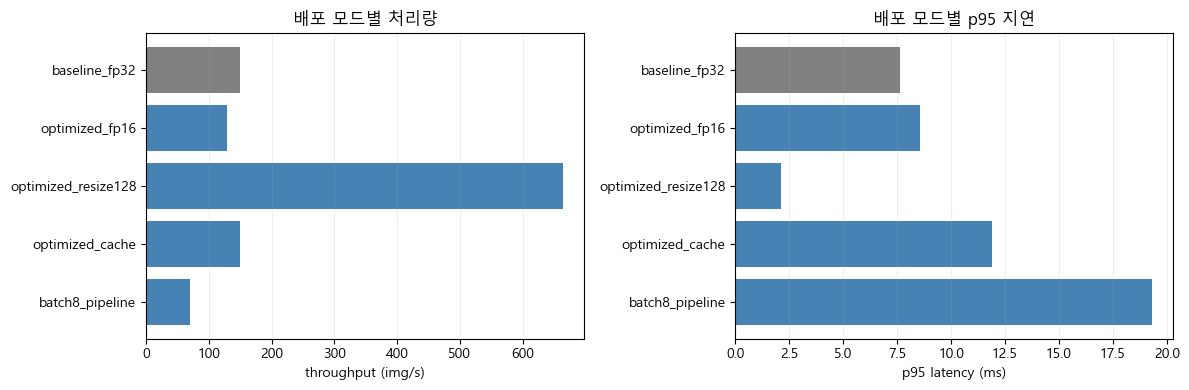

입력 메모리(KB): fp32=1406.2, fp16=703.1, resize128≈32.0


In [5]:
# 최적화 효과 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ["gray" if m == "baseline_fp32" else "steelblue" for m in bench_df["mode"]]
axes[0].barh(bench_df["mode"], bench_df["throughput"], color=colors)
axes[0].set_xlabel("throughput (img/s)")
axes[0].set_title("배포 모드별 처리량")
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.2)

axes[1].barh(bench_df["mode"], bench_df["p95_ms"], color=colors)
axes[1].set_xlabel("p95 latency (ms)")
axes[1].set_title("배포 모드별 p95 지연")
axes[1].invert_yaxis()
axes[1].grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

# 메모리 footprint
mem_fp32 = images_fp32[0].nbytes / 1024
mem_fp16 = images_fp32[0].astype(np.float16).nbytes / 1024
mem_128 = (128 * 128 * 2) / 1024  # uint8 resize approx
print(f"입력 메모리(KB): fp32={mem_fp32:.1f}, fp16={mem_fp16:.1f}, resize128≈{mem_128:.1f}")

## 4) 최적화 vs 정확도 Trade-off

배포 최적화는 **속도·메모리 이득**과 **feature 정확도 유지** 사이 trade-off입니다.

,mode,mean_feature_l2_diff,max_feature_l2_diff,cosine_sim_mean,throughput
0,fp32_baseline,0.0000,0.0000,1.0000,148.7902
1,fp16,0.0002,0.0002,1.0000,128.4997
2,resize128,0.0739,0.0839,0.9957,664.9184
3,resize64,0.0974,0.1110,0.9927,NaN


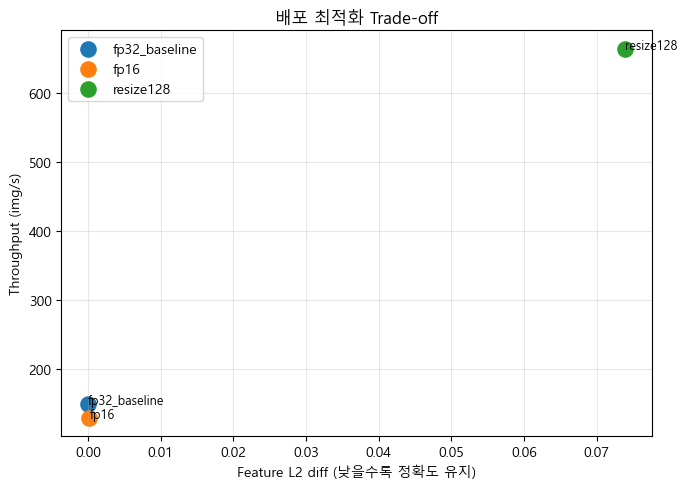

In [6]:
modes = {
    "fp32_baseline": infer_features_fp32,
    "fp16": infer_features_fp16,
    "resize128": lambda g: infer_features_resized(g, 128),
    "resize64": lambda g: infer_features_resized(g, 64),
}

bench_map = {
    "fp32_baseline": bench_df.loc[bench_df["mode"] == "baseline_fp32", "throughput"].iloc[0],
    "fp16": bench_df.loc[bench_df["mode"] == "optimized_fp16", "throughput"].iloc[0],
    "resize128": bench_df.loc[bench_df["mode"] == "optimized_resize128", "throughput"].iloc[0],
    "resize64": np.nan,
}

ref = np.vstack([infer_features_fp32(im) for im in images_fp32[:20]])
trade_rows = []

for name, fn in modes.items():
    feats = np.vstack([fn(im) for im in images_fp32[:20]])
    diff = np.linalg.norm(feats - ref, axis=1)
    cos_sims = [
        np.dot(ref[i], feats[i]) / (np.linalg.norm(ref[i]) * np.linalg.norm(feats[i]) + 1e-9)
        for i in range(len(ref))
    ]
    trade_rows.append({
        "mode": name,
        "mean_feature_l2_diff": float(diff.mean()),
        "max_feature_l2_diff": float(diff.max()),
        "cosine_sim_mean": float(np.mean(cos_sims)),
        "throughput": float(bench_map.get(name, np.nan)),
    })

trade_df = pd.DataFrame(trade_rows)
display(trade_df.round(4))

plt.figure(figsize=(7, 5))
plot_df = trade_df.dropna(subset=["throughput"])
for _, r in plot_df.iterrows():
    plt.scatter(r["mean_feature_l2_diff"], r["throughput"], s=120, label=r["mode"])
    plt.annotate(r["mode"], (r["mean_feature_l2_diff"], r["throughput"]), fontsize=9)
plt.xlabel("Feature L2 diff (낮을수록 정확도 유지)")
plt.ylabel("Throughput (img/s)")
plt.title("배포 최적화 Trade-off")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 5) Production 전환 로드맵

| Phase | 기간 | 목표 | 산출물 |
|-------|------|------|--------|
| P0 | 완료 | PoC 검증 | 노트북 01~16 |
| P1 | 4주 | 실측 센서 + YOLO 학습 모델 | ONNX/TorchScript |
| P2 | 4주 | Edge 배포 + 모니터링 실연동 | Docker + Grafana |
| P3 | 8주 | 파일럿 라인 | KPI 리포트, ROI 검증 |

In [7]:
ROADMAP = [
    {"phase": "P1", "week": "1-2", "task": "실측 센서 API + 스키마 고정", "owner": "데이터", "deliverable": "sensor_api_spec.json"},
    {"phase": "P1", "week": "2-3", "task": "YOLOv8 학습 + mAP@0.5 ≥ baseline", "owner": "ML", "deliverable": "weights/best.pt"},
    {"phase": "P1", "week": "3-4", "task": "ONNX export + TensorRT/ORT 벤치", "owner": "ML", "deliverable": "model.onnx"},
    {"phase": "P2", "week": "5-6", "task": "FastAPI 컨테이너화 + health/analyze", "owner": "인프라", "deliverable": "Docker image"},
    {"phase": "P2", "week": "6-7", "task": "Prometheus 메트릭 + Grafana 대시보드", "owner": "운영", "deliverable": "dashboards/"},
    {"phase": "P2", "week": "7-8", "task": "피드백 승인 워크플로", "owner": "품질", "deliverable": "feedback_workflow.md"},
    {"phase": "P3", "week": "9-12", "task": "1라인 파일럿 + KPI 측정", "owner": "전체", "deliverable": "pilot_report.pdf"},
    {"phase": "P3", "week": "13-16", "task": "ROI 검증 + 확장 결정", "owner": "경영", "deliverable": "go_no_go_decision"},
]

roadmap_df = pd.DataFrame(ROADMAP)
display(roadmap_df)

# 권장 배포 설정 (PoC 한계 기반)
DEPLOY_RECOMMENDATION = {
    "inference": {
        "precision": "fp16",
        "input_resize": 256,
        "batch_size": 8,
        "enable_cache": True,
        "model_format": "onnx",
        "runtime": "onnxruntime-gpu",
    },
    "sla_targets": {
        "p95_latency_ms": 100,
        "throughput_img_s_min": 30,
        "availability": 0.995,
    },
    "poc_gaps_to_close": limits_df[limits_df["severity"] == "high"][["id", "limit", "mitigation"]].to_dict(orient="records"),
    "recommended_mode_from_bench": bench_df.loc[bench_df["speedup_vs_baseline"].idxmax(), "mode"],
    "optimization_summary": {
        "best_speedup": float(bench_df["speedup_vs_baseline"].max()),
        "best_mode": bench_df.loc[bench_df["speedup_vs_baseline"].idxmax(), "mode"],
        "cache_hit_rate": cache.hits / (cache.hits + cache.misses + 1e-9),
    },
}

print(json.dumps(DEPLOY_RECOMMENDATION, indent=2, ensure_ascii=False))

,phase,week,task,owner,deliverable
0,P1,1-2,실측 센서 API + 스키마 고정,데이터,sensor_api_spec.json
1,P1,2-3,YOLOv8 학습 + mAP@0.5 ≥ baseline,ML,weights/best.pt
2,P1,3-4,ONNX export + TensorRT/ORT 벤치,ML,model.onnx
3,P2,5-6,FastAPI 컨테이너화 + health/analyze,인프라,Docker image
4,P2,6-7,Prometheus 메트릭 + Grafana 대시보드,운영,dashboards/
5,P2,7-8,피드백 승인 워크플로,품질,feedback_workflow.md
6,P3,9-12,1라인 파일럿 + KPI 측정,전체,pilot_report.pdf
7,P3,13-16,ROI 검증 + 확장 결정,경영,go_no_go_decision


{
  "inference": {
    "precision": "fp16",
    "input_resize": 256,
    "batch_size": 8,
    "enable_cache": true,
    "model_format": "onnx",
    "runtime": "onnxruntime-gpu"
  },
  "sla_targets": {
    "p95_latency_ms": 100,
    "throughput_img_s_min": 30,
    "availability": 0.995
  },
  "poc_gaps_to_close": [
    {
      "id": "D1",
      "limit": "이미지-라벨 불일치 stem 존재",
      "mitigation": "정제 파이프라인 + 품질 게이트"
    },
    {
      "id": "D2",
      "limit": "센서 데이터 시뮬레이션 의존",
      "mitigation": "실측 센서 API 연동"
    },
    {
      "id": "M1",
      "limit": "Rule-based risk score (학습 모델 미배포)",
      "mitigation": "YOLO/CNN 학습 모델 배포"
    },
    {
      "id": "S1",
      "limit": "인프로세스 웹서비스 (분산/오토스케일 없음)",
      "mitigation": "컨테이너 + K8s/Edge 배포"
    }
  ],
  "recommended_mode_from_bench": "optimized_resize128",
  "optimization_summary": {
    "best_speedup": 4.468832623332596,
    "best_mode": "optimized_resize128",
    "cache_hit_rate": 0.5099999999949
  }
}


In [8]:
# 산출물 저장
limits_df.to_csv(OUT_DIR / "poc_limits_catalog.csv", index=False, encoding="utf-8-sig")
MATURITY.to_csv(OUT_DIR / "maturity_gap_analysis.csv", index=False, encoding="utf-8-sig")
bench_df.to_csv(OUT_DIR / "deployment_optimization_benchmark.csv", index=False, encoding="utf-8-sig")
trade_df.to_csv(OUT_DIR / "optimization_accuracy_tradeoff.csv", index=False, encoding="utf-8-sig")
roadmap_df.to_csv(OUT_DIR / "production_roadmap.csv", index=False, encoding="utf-8-sig")

final_report = {
    "title": "PoC Limitations & Deployment Optimization Report",
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "overall_maturity": {"poc": float(overall_poc), "target": float(overall_target), "gap": float(overall_gap)},
    "high_severity_limits": int((limits_df["severity"] == "high").sum()),
    "deployment_recommendation": DEPLOY_RECOMMENDATION,
    "benchmark_top_mode": bench_df.loc[bench_df["throughput"].idxmax()].to_dict(),
    "next_actions": [
        "HIGH severity 한계 5건 우선 해결",
        "YOLO 학습 모델 ONNX export",
        "실측 센서 2주 파일럿 데이터 수집",
        "Grafana 대시보드 프로덕션 연동",
    ],
}

with open(OUT_DIR / "poc_limits_deployment_report.json", "w", encoding="utf-8") as f:
    json.dump(final_report, f, ensure_ascii=False, indent=2)

print("저장 완료:")
for fn in [
    "poc_limits_catalog.csv",
    "maturity_gap_analysis.csv",
    "deployment_optimization_benchmark.csv",
    "optimization_accuracy_tradeoff.csv",
    "production_roadmap.csv",
    "poc_limits_deployment_report.json",
]:
    print("-", OUT_DIR / fn)

저장 완료:
- C:\MyCursorLab\10_프로젝트\outputs\poc_limits_deployment\poc_limits_catalog.csv
- C:\MyCursorLab\10_프로젝트\outputs\poc_limits_deployment\maturity_gap_analysis.csv
- C:\MyCursorLab\10_프로젝트\outputs\poc_limits_deployment\deployment_optimization_benchmark.csv
- C:\MyCursorLab\10_프로젝트\outputs\poc_limits_deployment\optimization_accuracy_tradeoff.csv
- C:\MyCursorLab\10_프로젝트\outputs\poc_limits_deployment\production_roadmap.csv
- C:\MyCursorLab\10_프로젝트\outputs\poc_limits_deployment\poc_limits_deployment_report.json


## 실습 과제

1. `POC_LIMITS`에 팀이 발견한 한계 3건을 추가하고 severity를 재평가하세요.
2. `resize64` 모드의 throughput vs feature diff를 측정해 배포 적합 여부를 판단하세요.
3. ONNX export 스크립트 스켈레톤을 작성하고 벤치에 추가하세요.
4. Production 로드맵 P1 태스크에 담당자·마감일을 채우세요.

---

### 한 줄 정리
PoC의 가치는 **한계를 명확히 문서화**하고, **배포 최적화로 갭을 줄이는 로드맵**을 만드는 데 있습니다.